In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from Bio.SeqUtils import IUPACData

In [2]:
AMINO_ACID_CLASSIFICATIONS = {
    'ALA': 'non-polar',
    'CYS': 'polar',
    'ASP': 'negative',
    'GLU': 'negative',
    'PHE': 'non-polar',
    'GLY': 'non-polar',
    'HIS': 'positive',
    'ILE': 'non-polar',
    'LYS': 'positive',
    'LEU': 'non-polar',
    'MET': 'non-polar',
    'ASN': 'polar',
    'PRO': 'non-polar',
    'GLN': 'polar',
    'ARG': 'positive',
    'SER': 'polar',
    'THR': 'polar',
    'VAL': 'non-polar',
    'TRP': 'non-polar',
    'TYR': 'polar',
}

INTERACTION_CLASSIFICATIONS = {
    ('non-polar', 'non-polar'): 'hydrophobic',
    ('polar', 'polar'): 'hydrophilic',
    ('negative', 'positive'): 'electrostatic',
}

## TCR

In [3]:
tcr_pmhc_contacting_residues = pd.read_csv('data/interim/tcr_pmhc_contacting_residues.csv')

### Classifying the interaction types

In [4]:
tcr_pmhc_contacting_residues['interaction_classification'] = (
    tcr_pmhc_contacting_residues[['residue_name_tcr', 'residue_name_pmhc']]
    .map(lambda res_name: AMINO_ACID_CLASSIFICATIONS[res_name])
    .apply(lambda row: tuple(sorted(row)), axis=1)
    .map(lambda interaction: INTERACTION_CLASSIFICATIONS.get(interaction, interaction))
    .apply(str)
)

In [5]:
tcr_pmhc_contacting_residues['mhc_component'] = tcr_pmhc_contacting_residues['chain_type_pmhc'].map(
    lambda chain_type: 'peptide' if chain_type == 'antigen_chain' else 'mhc',
)

In [6]:
tcr_pmhc_contacting_residues['proportion_mhc_type_norm'] = tcr_pmhc_contacting_residues.groupby('mhc_type')[
    'proportion'
].transform(lambda proportions: proportions / proportions.sum())

In [7]:
tcr_pmhc_contacting_residues['proportion_mhc_type_mhc_component_norm'] = tcr_pmhc_contacting_residues.groupby(
    ['mhc_type', 'mhc_component']
)['proportion'].transform(lambda proportions: proportions / proportions.sum())

In [8]:
tcr_pmhc_contacting_residues['proportion_mhc_type_mhc_component_cdr_type_norm'] = tcr_pmhc_contacting_residues.groupby(
    ['mhc_type', 'mhc_component', 'cdr_type']
)['proportion'].transform(lambda group: group / group.sum())

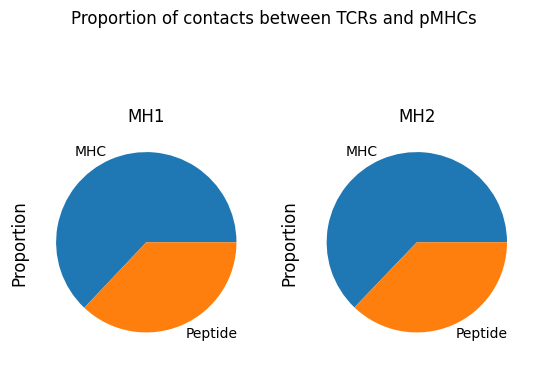

In [9]:
grouped = tcr_pmhc_contacting_residues.groupby(['mhc_type', 'mhc_component'])['proportion_mhc_type_norm'].sum()

grouped.index = pd.MultiIndex.from_arrays(
    [grouped.index.get_level_values(0), grouped.index.get_level_values(1).map({'peptide': 'Peptide', 'mhc': 'MHC'})]
)

fig, axes = plt.subplots(1, 2)

grouped['MH1'].sort_index().plot.pie(title='MH1', ax=axes[0])
grouped['MH2'].sort_index().plot.pie(title='MH2', ax=axes[1])

plt.suptitle('Proportion of contacts between TCRs and pMHCs')

axes[0].set_ylabel('Proportion', fontsize=12)
axes[1].set_ylabel('Proportion', fontsize=12)

plt.show()

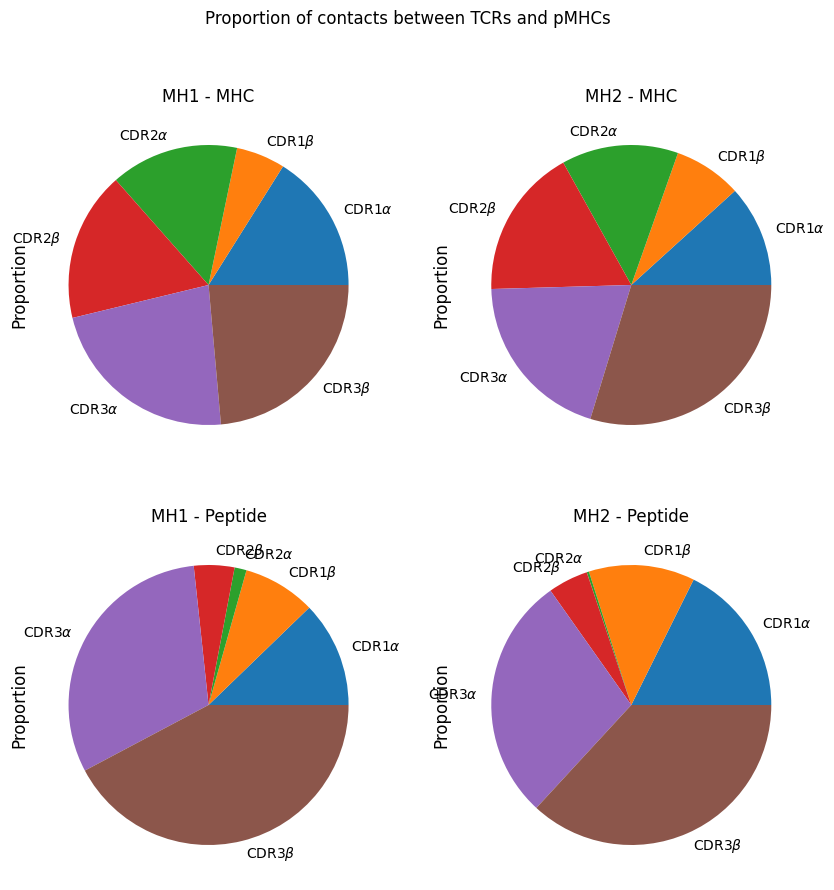

In [10]:
grouped = tcr_pmhc_contacting_residues.groupby(['mhc_type', 'mhc_component', 'cdr_type'])[
    'proportion_mhc_type_mhc_component_norm'
].sum()

grouped.index = pd.MultiIndex.from_arrays(
    [
        grouped.index.get_level_values(0),
        grouped.index.get_level_values(1).map({'peptide': 'Peptide', 'mhc': 'MHC'}),
        grouped.index.get_level_values(2).map(
            {
                f'CDR{number}{chain_type}': f'CDR{number}$\\{chain_type}$'
                for chain_type in ('alpha', 'beta')
                for number in (1, 2, 3)
            }
        ),
    ]
)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
plt.suptitle('Proportion of contacts between TCRs and pMHCs')

for j, mhc_type in enumerate(('MH1', 'MH2')):
    for i, mhc_component in enumerate(('MHC', 'Peptide')):
        grouped[mhc_type][mhc_component].sort_index().plot.pie(title=f'{mhc_type} - {mhc_component}', ax=axes[i, j])

        axes[i, j].set_ylabel('Proportion', fontsize=12)


plt.show()

In [11]:
tcr_pmhc_contacting_residues_agg = (
    tcr_pmhc_contacting_residues.groupby(['mhc_type', 'mhc_component', 'interaction_classification'])[
        'proportion_mhc_type_mhc_component_norm'
    ]
    .sum()
    .reset_index()
)

In [12]:
tcr_pmhc_contacting_residues_agg['sort_col'] = tcr_pmhc_contacting_residues_agg.groupby(
    ['mhc_type', 'interaction_classification']
)['proportion_mhc_type_mhc_component_norm'].transform('mean')
tcr_pmhc_contacting_residues_agg = tcr_pmhc_contacting_residues_agg.sort_values(
    ['mhc_type', 'sort_col'], ascending=[True, False]
)

tcr_pmhc_contacting_residues_agg = tcr_pmhc_contacting_residues_agg.drop('sort_col', axis='columns')

In [13]:
def _calculate_rmse(group: pd.DataFrame) -> float:
    group1 = group[group['mhc_component'] == 'peptide']
    group1 = group1.set_index('interaction_classification')
    group1 = group1.sort_index()

    group2 = group[group['mhc_component'] == 'mhc']
    group2 = group2.set_index('interaction_classification')
    group2 = group2.sort_index()

    return np.sqrt(
        np.sum(
            np.square(
                group2['proportion_mhc_type_mhc_component_norm'] - group1['proportion_mhc_type_mhc_component_norm']
            )
        )
        / len(group1)
    )


rmses = tcr_pmhc_contacting_residues_agg.groupby('mhc_type').apply(_calculate_rmse, include_groups=False)

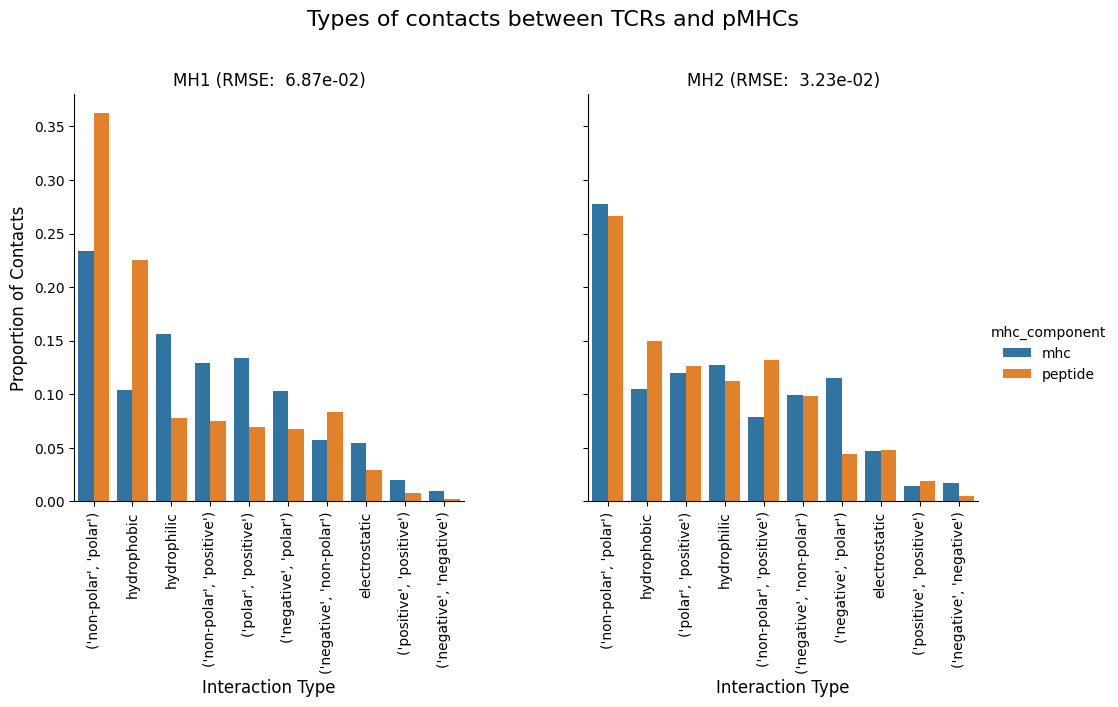

In [14]:
grid = sns.catplot(
    tcr_pmhc_contacting_residues_agg,
    col='mhc_type',
    hue='mhc_component',
    x='interaction_classification',
    y='proportion_mhc_type_mhc_component_norm',
    kind='bar',
    sharex=False,
)


for i, ax in enumerate(grid.axes.flat):
    plt.setp(ax.get_xticklabels(), rotation=90)
    ax.set_xlabel('Interaction Type', fontsize=12)

    if i == 0:
        ax.set_ylabel('Proportion of Contacts', fontsize=12)

for ax, title in zip(grid.axes.flat, grid.col_names, strict=True):
    ax.set_title(f'{title} (RMSE: {rmses[title]: .2e})')

plt.suptitle('Types of contacts between TCRs and pMHCs', y=1.10, fontsize=16)

plt.show()

In [15]:
tcr_pmhc_contacting_residues_cdr_type_agg = (
    tcr_pmhc_contacting_residues.groupby(['mhc_type', 'mhc_component', 'cdr_type', 'interaction_classification'])[
        'proportion_mhc_type_mhc_component_cdr_type_norm'
    ]
    .sum()
    .reset_index()
)

In [16]:
tcr_pmhc_contacting_residues_cdr_type_agg['sort_col'] = tcr_pmhc_contacting_residues_cdr_type_agg.groupby(
    ['mhc_type', 'cdr_type', 'interaction_classification']
)['proportion_mhc_type_mhc_component_cdr_type_norm'].transform('mean')
tcr_pmhc_contacting_residues_cdr_type_agg = tcr_pmhc_contacting_residues_cdr_type_agg.sort_values(
    ['mhc_type', 'cdr_type', 'sort_col'], ascending=[True, True, False]
)

tcr_pmhc_contacting_residues_cdr_type_agg = tcr_pmhc_contacting_residues_cdr_type_agg.drop('sort_col', axis='columns')

In [17]:
def _calculate_rmse(group: pd.DataFrame) -> float:
    group1 = group[group['mhc_component'] == 'peptide']
    group1 = group1.set_index('interaction_classification')
    group1 = group1.sort_index()

    group2 = group[group['mhc_component'] == 'mhc']
    group2 = group2.set_index('interaction_classification')
    group2 = group2.sort_index()

    return np.sqrt(
        np.sum(
            np.square(
                group2['proportion_mhc_type_mhc_component_cdr_type_norm']
                - group1['proportion_mhc_type_mhc_component_cdr_type_norm']
            )
        )
        / len(group1)
    )


rmses = tcr_pmhc_contacting_residues_cdr_type_agg.groupby(['mhc_type', 'cdr_type']).apply(
    _calculate_rmse, include_groups=False
)

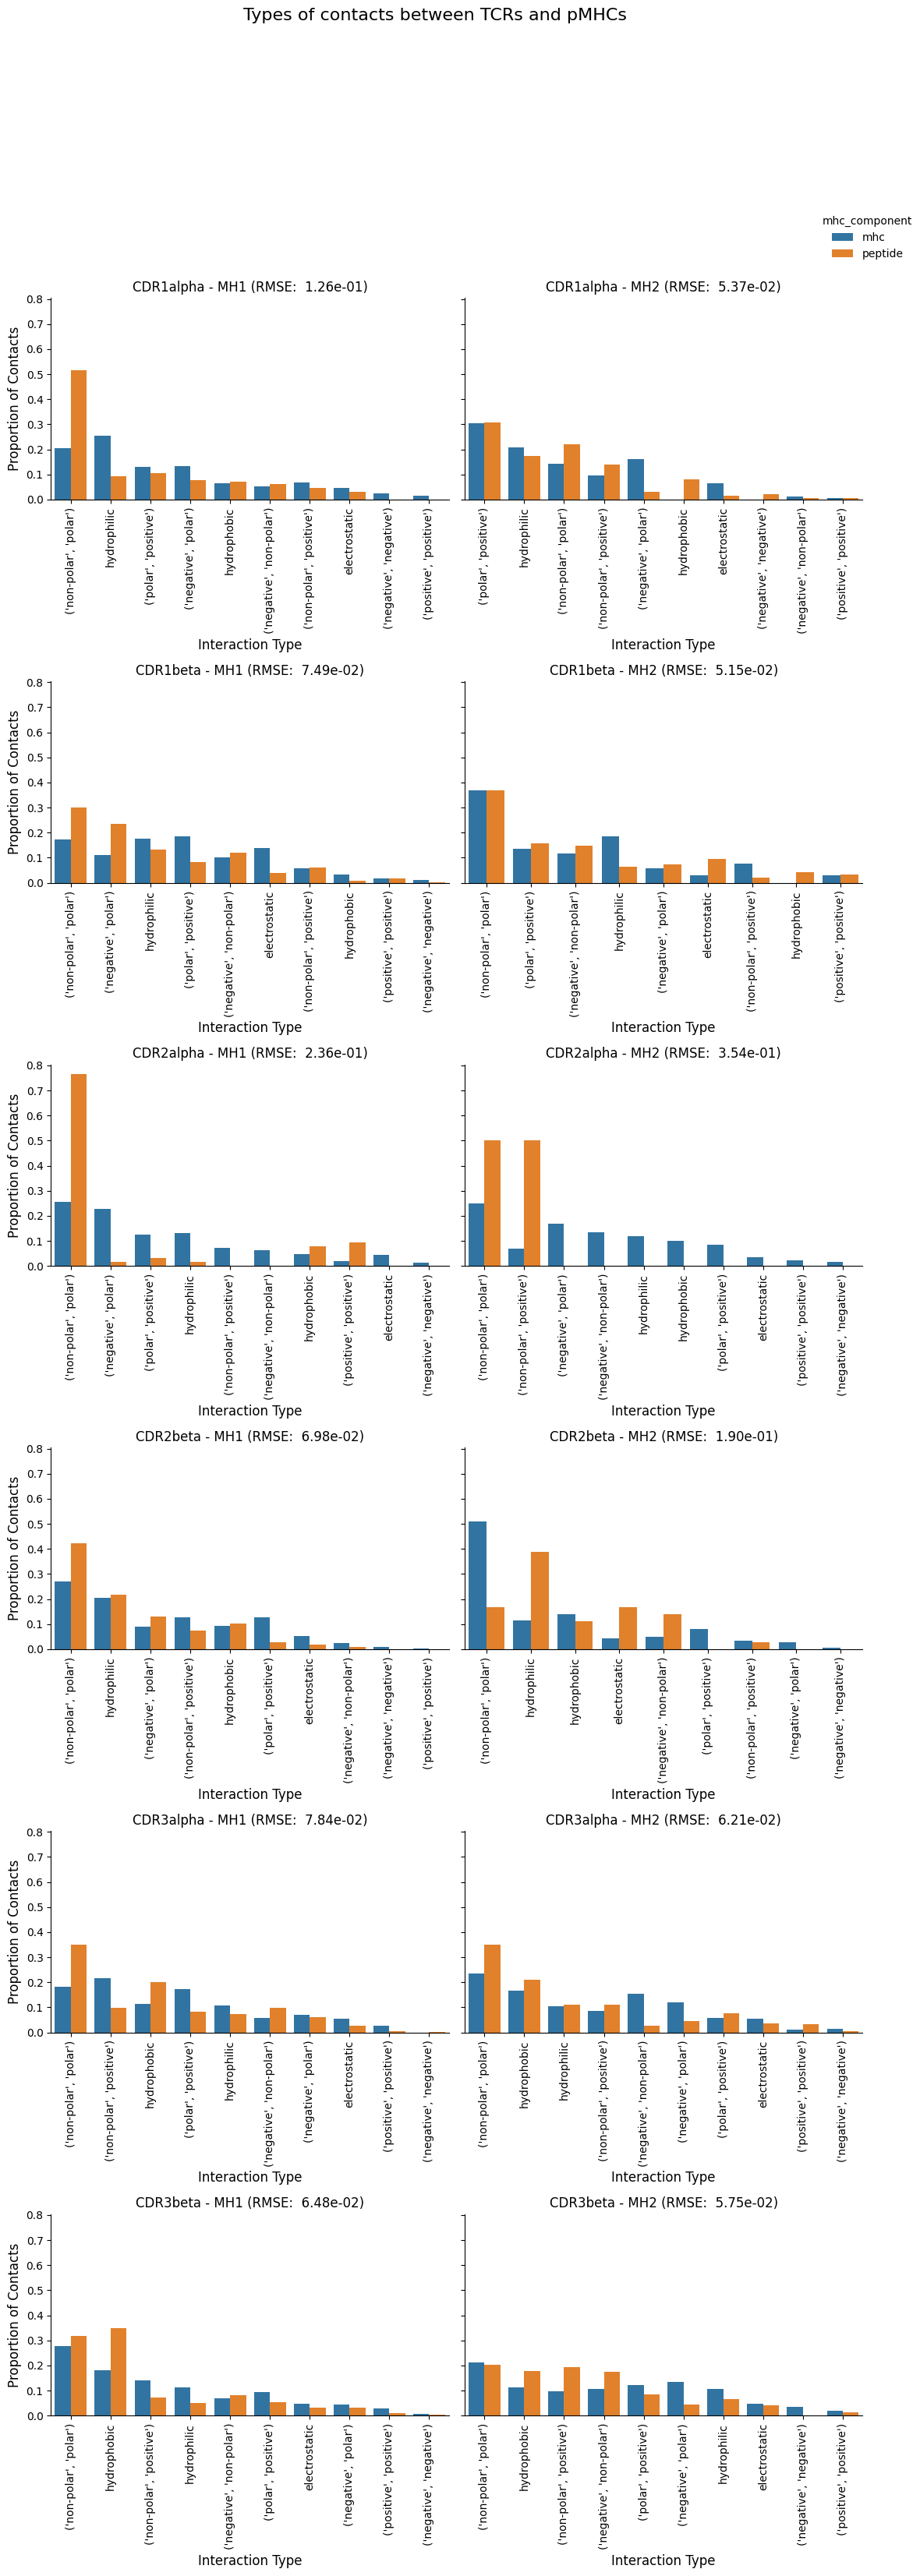

In [18]:
grid = sns.catplot(
    tcr_pmhc_contacting_residues_cdr_type_agg,
    row='cdr_type',
    col='mhc_type',
    hue='mhc_component',
    x='interaction_classification',
    y='proportion_mhc_type_mhc_component_cdr_type_norm',
    kind='bar',
    sharex=False,
)

for i, ax in enumerate(grid.axes.flat):
    plt.setp(ax.get_xticklabels(), rotation=90)
    ax.set_xlabel('Interaction Type', fontsize=12)

    if i % 2 == 0:
        ax.set_ylabel('Proportion of Contacts', fontsize=12)

for i, ax in enumerate(grid.axes.flat):
    row_idx = i // len(grid.col_names)
    col_idx = i % len(grid.col_names)

    cdr_type = grid.row_names[row_idx]
    mhc_type = grid.col_names[col_idx]

    rmse = rmses[mhc_type][cdr_type]

    ax.set_title(f'{cdr_type} - {mhc_type} (RMSE: {rmse: .2e})')

plt.suptitle('Types of contacts between TCRs and pMHCs', y=1.10, fontsize=16)
plt.tight_layout()
grid.legend.set_bbox_to_anchor((1.05, 1))

plt.show()

### Creating interaction tables

In [19]:
tcr_pmhc_contacting_residues[['res_olc_tcr', 'res_olc_pmhc']] = tcr_pmhc_contacting_residues[
    ['residue_name_tcr', 'residue_name_pmhc']
].map(
    lambda residue: IUPACData.protein_letters_3to1[residue.title()],
)

In [20]:
def process_tcr_pmhc_interactions(contacting_residues: pd.DataFrame) -> pd.DataFrame:
    contacting_residues = contacting_residues.copy()

    contacting_residues['proportion'] = contacting_residues['proportion'] / contacting_residues['proportion'].sum()
    contacting_residues = contacting_residues.pivot_table(
        index='res_olc_tcr', columns='res_olc_pmhc', values='proportion'
    ).fillna(0)

    return contacting_residues

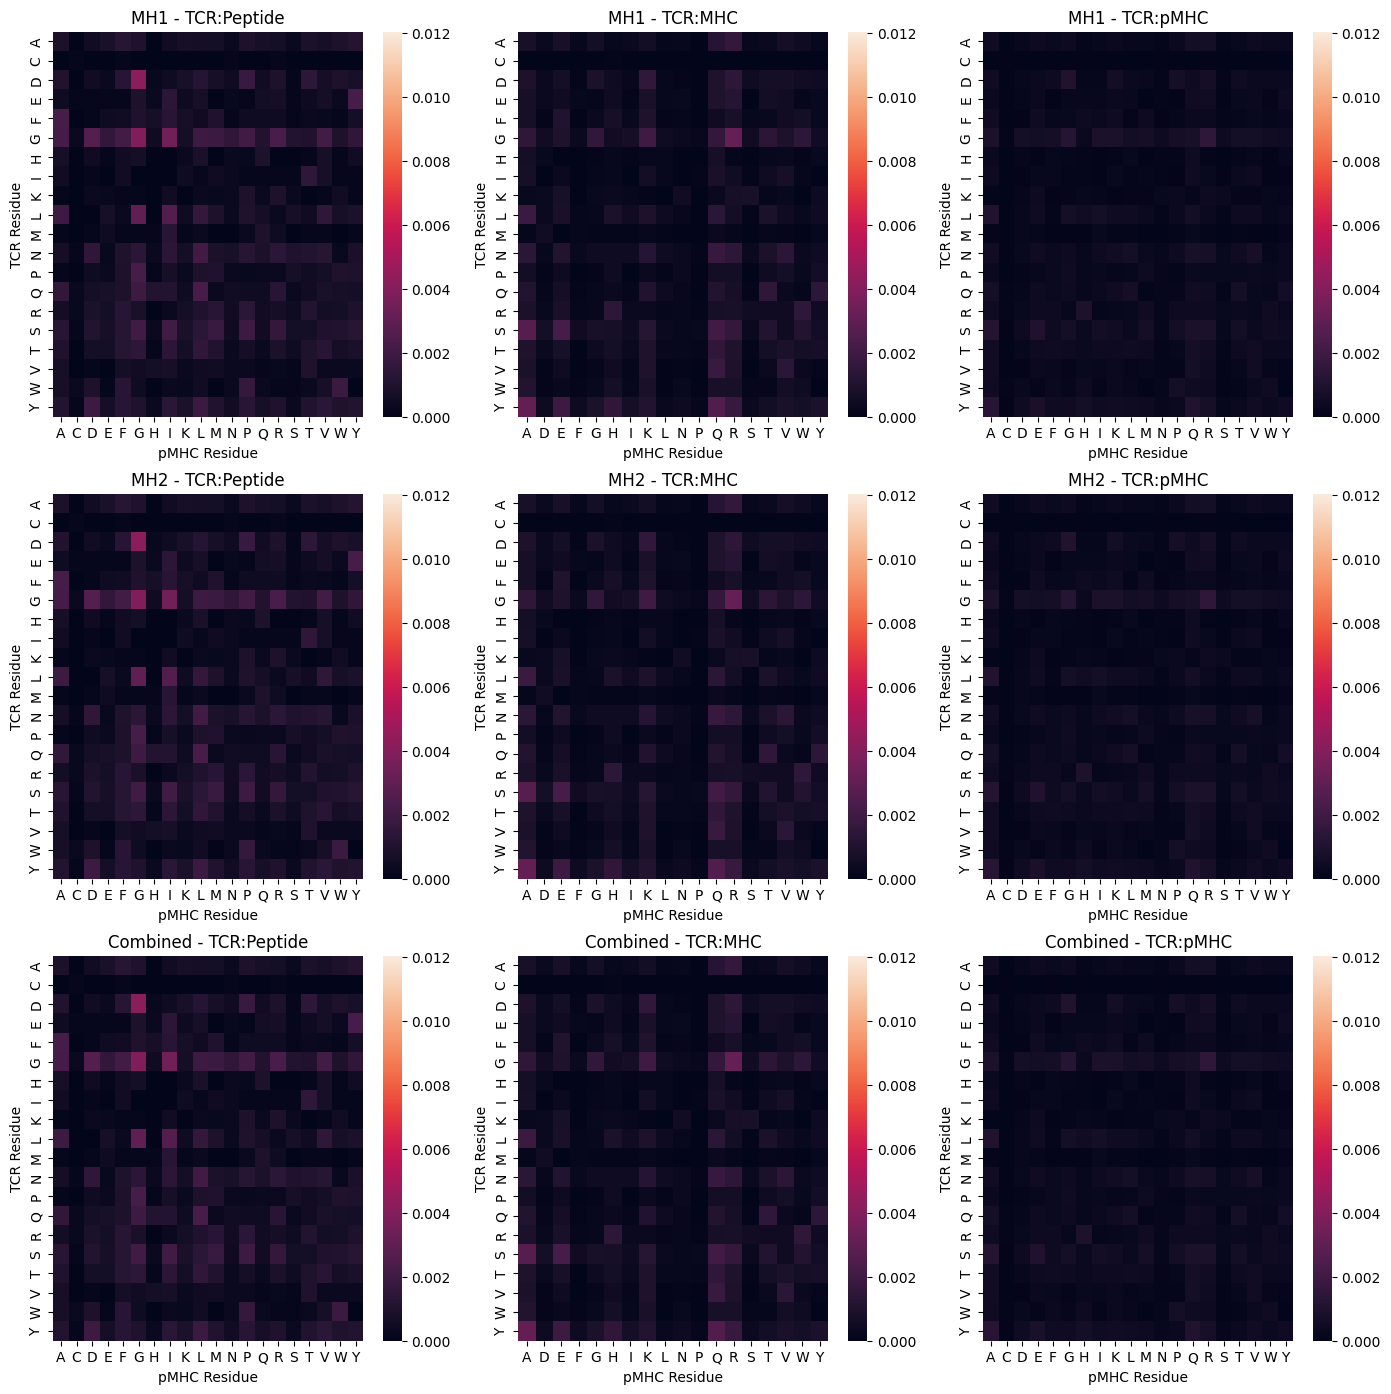

In [21]:
tables = [[None] * 3] * 3

maximum = 0

for i, mhc_type in enumerate(('MH1', 'MH2', 'Combined')):
    for j, mhc_component in enumerate(('peptide', 'mhc', 'Combined')):
        contacting_residues = tcr_pmhc_contacting_residues

        if mhc_type != 'Combined':
            contacting_residues = contacting_residues[contacting_residues['mhc_type'] == mhc_type]

        if mhc_component != 'Combined':
            contacting_residues = contacting_residues[contacting_residues['mhc_component'] == mhc_component]

        table = process_tcr_pmhc_interactions(contacting_residues)

        table_max = table.max().max()

        maximum = max(table_max, maximum)

        tables[i][j] = table


fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(17, 17))
title_key = {'peptide': 'TCR:Peptide', 'mhc': 'TCR:MHC', 'Combined': 'TCR:pMHC'}

for i, mhc_type in enumerate(('MH1', 'MH2', 'Combined')):
    for j, mhc_component in enumerate(('peptide', 'mhc', 'Combined')):
        sns.heatmap(tables[i][j], vmax=maximum, ax=axes[i, j])

        axes[i, j].set_title(f'{mhc_type} - {title_key.get(mhc_component, mhc_component)}')

        axes[i, j].set_xlabel('pMHC Residue')
        axes[i, j].set_ylabel('TCR Residue')

## PPIs

In [22]:
ppi_contacting_residues = pd.read_csv('data/interim/ppi_contacting_residues.csv')

ppi_contacting_residues = (
    ppi_contacting_residues.groupby('interaction_type')
    .filter(lambda group: group['proportion_mean'].sum() > 0)
    .reset_index(drop=True)
)

In [23]:
def add_standard_deviations(standard_deviations: np.array) -> float:
    return np.sqrt(np.sum(np.square(standard_deviations)))

In [24]:
ppi_contacting_residues_protein_protein_interactions = ppi_contacting_residues[
    ppi_contacting_residues['interaction_type'] == 'protein_protein_interaction'
].copy()

ppi_contacting_residues_other_interactions = ppi_contacting_residues[
    ppi_contacting_residues['interaction_type'] != 'protein_protein_interaction'
].copy()

ppi_contacting_residues_protein_protein_interactions[['residue_name_1', 'residue_name_2']] = (
    ppi_contacting_residues_protein_protein_interactions[['residue_name_1', 'residue_name_2']].apply(
        lambda row: pd.Series(sorted(row)), axis=1
    )
)

ppi_contacting_residues_protein_protein_interactions = (
    ppi_contacting_residues_protein_protein_interactions.groupby(
        ['interaction_type', 'residue_name_1', 'residue_name_2']
    )
    .agg({'proportion_mean': 'sum', 'proportion_std': add_standard_deviations, 'sample_size': 'sum'})
    .reset_index()
)


ppi_contacting_residues = pd.concat(
    [ppi_contacting_residues_protein_protein_interactions, ppi_contacting_residues_other_interactions]
).reset_index(drop=True)

In [25]:
ppi_contacting_residues['proportion_mean_interaction_type_norm'] = ppi_contacting_residues.groupby('interaction_type')[
    'proportion_mean'
].transform(lambda group_propotion: group_propotion / group_propotion.sum())
ppi_contacting_residues['proportion_std_interaction_type_norm'] = (
    ppi_contacting_residues['proportion_mean_interaction_type_norm'] / ppi_contacting_residues['proportion_mean']
) * ppi_contacting_residues['proportion_std']

### Classifying the interaction types

In [26]:
ppi_contacting_residues['interaction_classification'] = (
    ppi_contacting_residues[['residue_name_1', 'residue_name_2']]
    .map(lambda res: AMINO_ACID_CLASSIFICATIONS[res])
    .apply(lambda row: tuple(sorted(row)), axis=1)
    .map(lambda interaction: INTERACTION_CLASSIFICATIONS.get(interaction, interaction))
)

In [27]:
ppi_contacting_residues_agg = (
    ppi_contacting_residues.groupby(['interaction_type', 'interaction_classification'])
    .agg(
        {
            'proportion_mean_interaction_type_norm': 'sum',
            'proportion_std_interaction_type_norm': add_standard_deviations,
            'sample_size': 'sum',
        }
    )
    .reset_index()
    .sort_values('proportion_mean_interaction_type_norm', ascending=False)
)

In [28]:
ppi_contacting_residues_agg_table = ppi_contacting_residues_agg.pivot_table(
    index='interaction_classification',
    columns='interaction_type',
    values=['proportion_mean_interaction_type_norm', 'proportion_std_interaction_type_norm', 'sample_size'],
).fillna(0)

In [29]:
ppi_contacting_residues_agg_table.index = ppi_contacting_residues_agg_table.index.map(str)

In [30]:
ppi_contacting_residues_agg_table['sort_col'] = ppi_contacting_residues_agg_table[
    'proportion_mean_interaction_type_norm'
].apply('mean', axis=1)
ppi_contacting_residues_agg_table = ppi_contacting_residues_agg_table.sort_values('sort_col', ascending=False)
ppi_contacting_residues_agg_table = ppi_contacting_residues_agg_table.drop('sort_col', axis='columns')

In [31]:
standard_error = ppi_contacting_residues_agg_table['proportion_std_interaction_type_norm'] / np.sqrt(
    ppi_contacting_residues_agg_table['sample_size']
)

standard_error.columns = pd.MultiIndex.from_product([['proportion_se_interaction_type_norm'], standard_error.columns])

ppi_contacting_residues_agg_table = pd.concat([ppi_contacting_residues_agg_table, standard_error], axis=1)

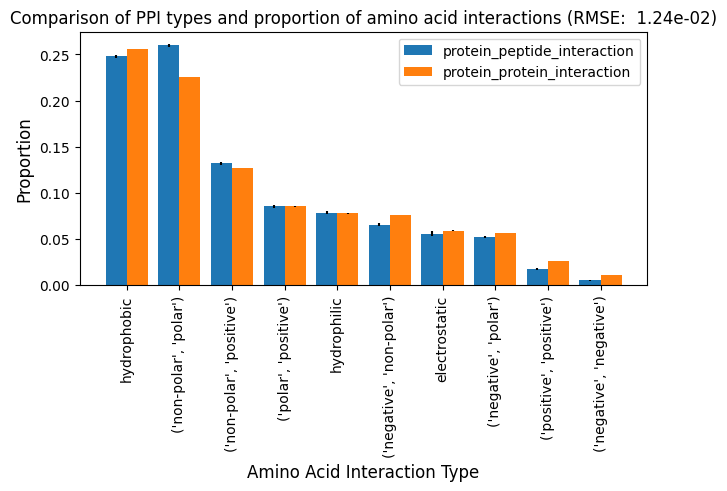

In [32]:
fig, ax = plt.subplots(layout='constrained')

rmse = np.sqrt(
    np.sum(
        np.square(
            ppi_contacting_residues_agg_table['proportion_mean_interaction_type_norm']['protein_peptide_interaction']
            - ppi_contacting_residues_agg_table['proportion_mean_interaction_type_norm']['protein_protein_interaction']
        )
    )
    / len(ppi_contacting_residues_agg_table)
)

x = np.arange(len(ppi_contacting_residues_agg_table.index))
width = 0.40

for multiplier, name in enumerate(ppi_contacting_residues_agg_table['proportion_mean_interaction_type_norm'].columns):
    offset = width * multiplier
    rects = ax.bar(
        x + offset,
        ppi_contacting_residues_agg_table['proportion_mean_interaction_type_norm'][name],
        width=width,
        label=name,
    )

    ax.errorbar(
        x + offset,
        ppi_contacting_residues_agg_table['proportion_mean_interaction_type_norm'][name],
        yerr=1.96 * ppi_contacting_residues_agg_table['proportion_se_interaction_type_norm'][name],
        ls='none',
        color='black',
    )


ax.set_xticks(x + width / 2, ppi_contacting_residues_agg_table.index, rotation=90)
ax.legend()

ax.set_title(f'Comparison of PPI types and proportion of amino acid interactions (RMSE: {rmse: .2e})')
ax.set_xlabel('Amino Acid Interaction Type', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)


plt.show()

### Creating the interaction tables

In [33]:
ppi_contacting_residues[['res_olc_1', 'res_olc_2']] = ppi_contacting_residues[['residue_name_1', 'residue_name_2']].map(
    lambda residue: IUPACData.protein_letters_3to1[residue.title()],
)

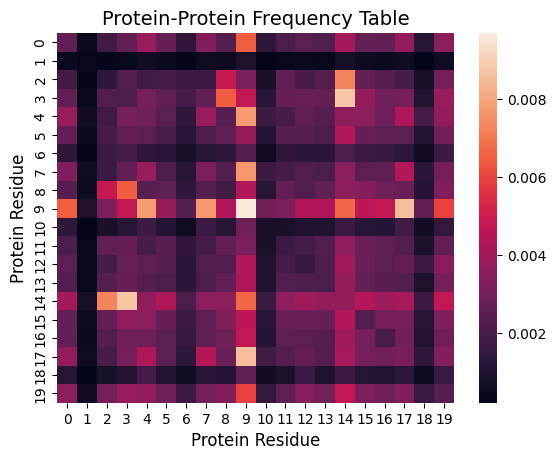

In [34]:
protein_protein_contacting_residues = ppi_contacting_residues[
    ppi_contacting_residues['interaction_type'] == 'protein_protein_interaction'
]

protein_protein_table = protein_protein_contacting_residues.pivot_table(
    index='res_olc_1', columns='res_olc_2', values='proportion_mean_interaction_type_norm'
).fillna(0.0)

protein_protein_table = np.maximum(protein_protein_table.to_numpy(), protein_protein_table.to_numpy().T)
protein_protein_table = protein_protein_table / protein_protein_table.sum()

sns.heatmap(protein_protein_table)

plt.title('Protein-Protein Frequency Table', fontsize=14)

plt.xlabel('Protein Residue', fontsize=12)
plt.ylabel('Protein Residue', fontsize=12)

plt.show()

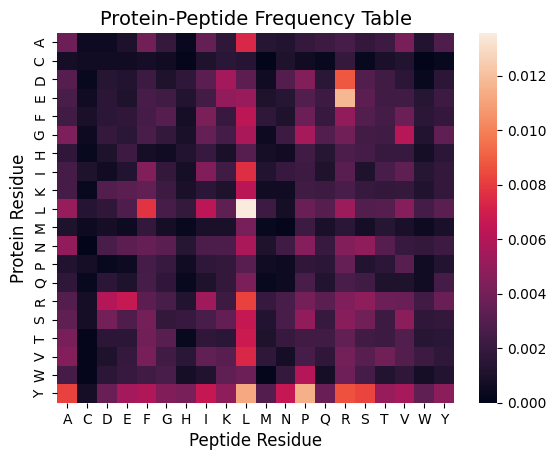

In [35]:
protein_peptide_contacting_residues = ppi_contacting_residues[
    ppi_contacting_residues['interaction_type'] == 'protein_peptide_interaction'
].copy()

protein_peptide_contacting_residues = protein_peptide_contacting_residues.rename(
    {
        'res_olc_1': 'protein_olc',
        'res_olc_2': 'peptide_olc',
    },
    axis='columns',
)

protein_peptide_table = protein_peptide_contacting_residues.pivot_table(
    index='protein_olc', columns='peptide_olc', values='proportion_mean_interaction_type_norm'
)

sns.heatmap(protein_peptide_table)

plt.title('Protein-Peptide Frequency Table', fontsize=14)

plt.xlabel('Peptide Residue', fontsize=12)
plt.ylabel('Protein Residue', fontsize=12)

plt.show()

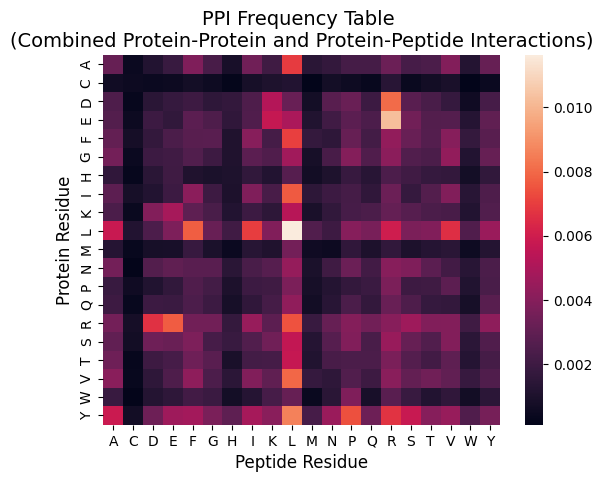

In [36]:
ppi_table = (protein_protein_table + protein_peptide_table) / 2

sns.heatmap(ppi_table)

plt.title('PPI Frequency Table \n(Combined Protein-Protein and Protein-Peptide Interactions)', fontsize=14)

plt.xlabel('Peptide Residue', fontsize=12)
plt.ylabel('Protein Residue', fontsize=12)

plt.show()

## Comparisons

In [37]:
tcr_pmhc_contacting_residues_agg['interaction_classification'] = tcr_pmhc_contacting_residues_agg[
    'interaction_classification'
].apply(str)

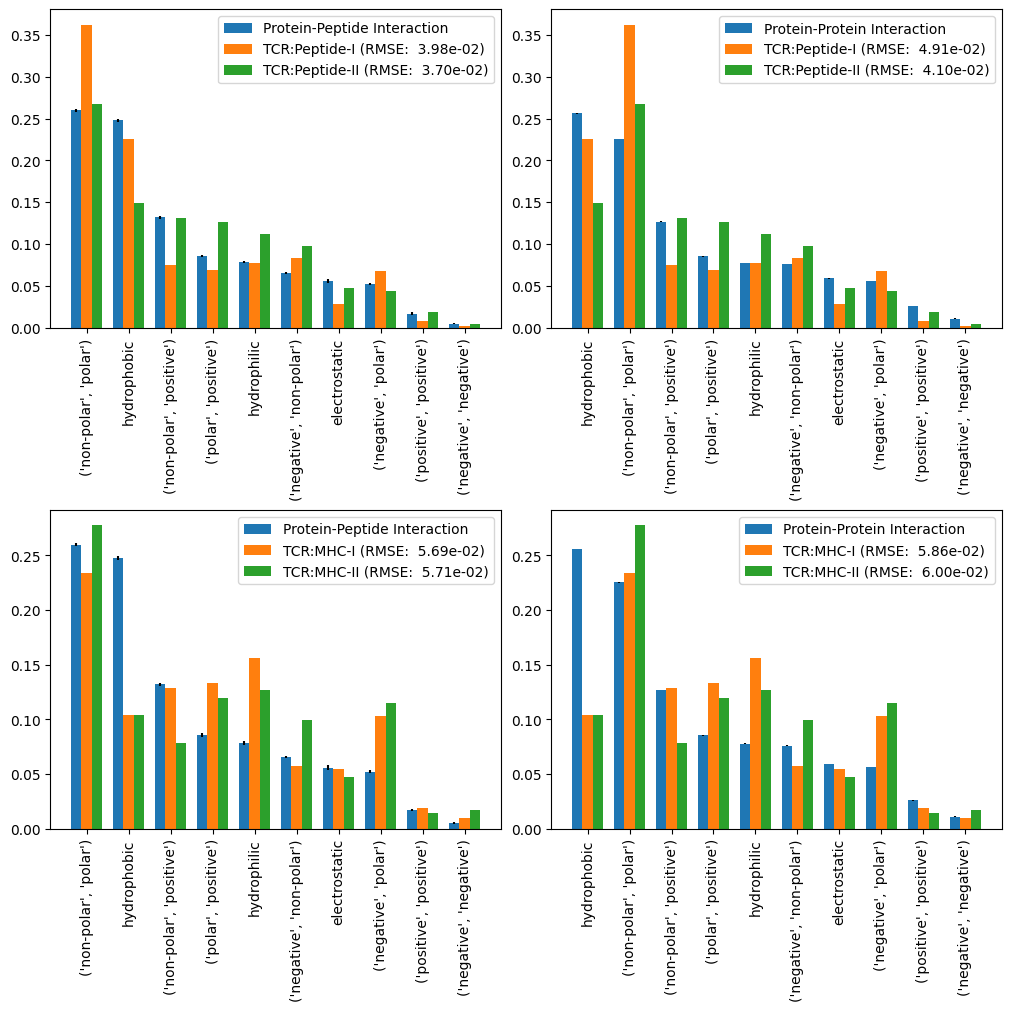

In [38]:
fig, axes = plt.subplots(nrows=2, ncols=2, layout='constrained', figsize=(10, 10))

for i, mhc_component in enumerate(('peptide', 'mhc')):
    for j, interaction_type in enumerate(('protein_peptide_interaction', 'protein_protein_interaction')):
        selected_ppi = ppi_contacting_residues_agg_table.sort_values(
            ('proportion_mean_interaction_type_norm', interaction_type), ascending=False
        )

        x = np.arange(len(selected_ppi.index))
        width = 0.25

        axes[i, j].bar(
            x,
            selected_ppi['proportion_mean_interaction_type_norm'][interaction_type],
            width=width,
            label=interaction_type.replace('_', ' ').title().replace(' ', '-', 1),
        )

        axes[i, j].errorbar(
            x,
            selected_ppi['proportion_mean_interaction_type_norm'][interaction_type],
            yerr=1.96 * selected_ppi['proportion_se_interaction_type_norm'][interaction_type],
            ls='none',
            color='black',
        )

        for multiplier, mhc_type in enumerate(('MH1', 'MH2'), 1):
            selected_tcr_mhc = tcr_pmhc_contacting_residues_agg[
                (tcr_pmhc_contacting_residues_agg['mhc_type'] == mhc_type)
                & (tcr_pmhc_contacting_residues_agg['mhc_component'] == mhc_component)
            ].copy()

            selected_tcr_mhc['interaction_classification'] = pd.Categorical(
                selected_tcr_mhc['interaction_classification'],
                categories=selected_ppi.index.tolist(),
                ordered=True,
            )
            selected_tcr_mhc = selected_tcr_mhc.sort_values('interaction_classification')
            selected_tcr_mhc = selected_tcr_mhc.set_index('interaction_classification')

            rmse = np.sqrt(
                np.sum(
                    np.square(
                        selected_ppi['proportion_mean_interaction_type_norm'][interaction_type]
                        - selected_tcr_mhc['proportion_mhc_type_mhc_component_norm']
                    )
                )
                / len(selected_ppi['proportion_mean_interaction_type_norm'][interaction_type])
            )
            label = (
                f"TCR:{'Peptide' if mhc_component == 'peptide' else 'MHC'}"
                f"-{'I' if mhc_type == 'MH1' else 'II'}"
                f" (RMSE: {rmse: .2e})"
            )

            axes[i, j].bar(
                x + multiplier * width,
                selected_tcr_mhc['proportion_mhc_type_mhc_component_norm'],
                width=width,
                label=label,
            )

        axes[i, j].set_xticks(x + width, selected_ppi.index, rotation=90)
        axes[i, j].legend()

plt.show()

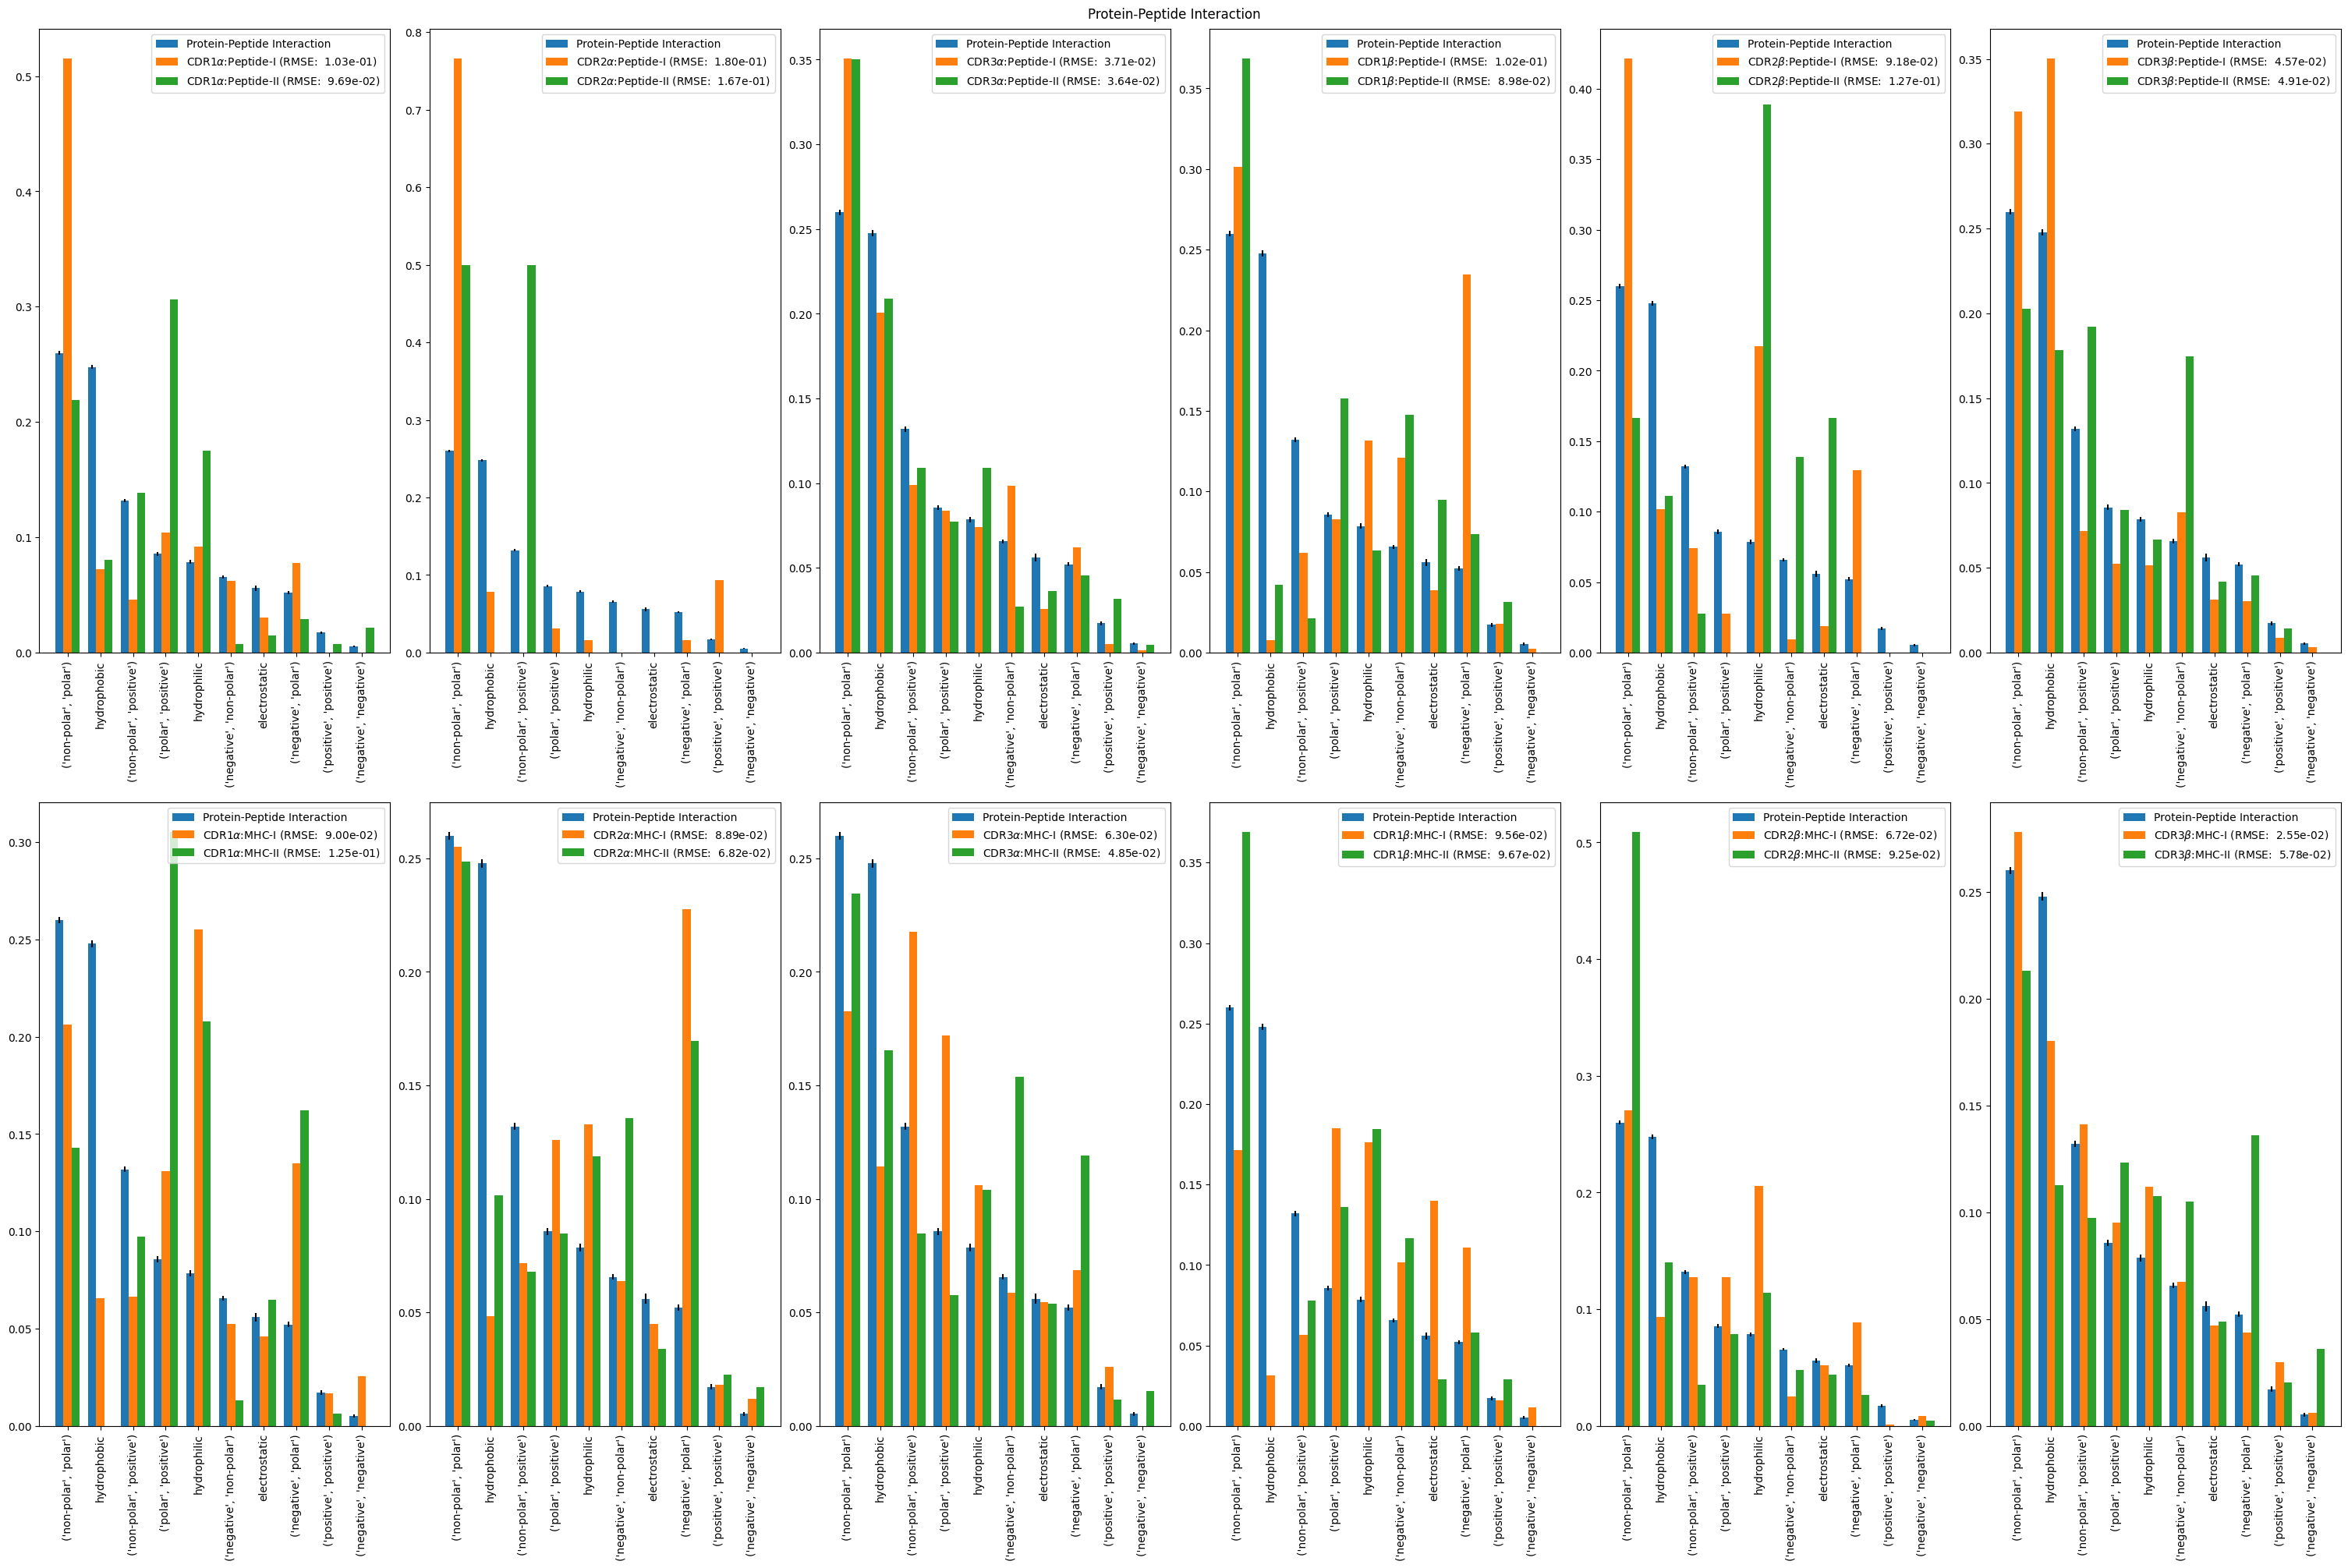

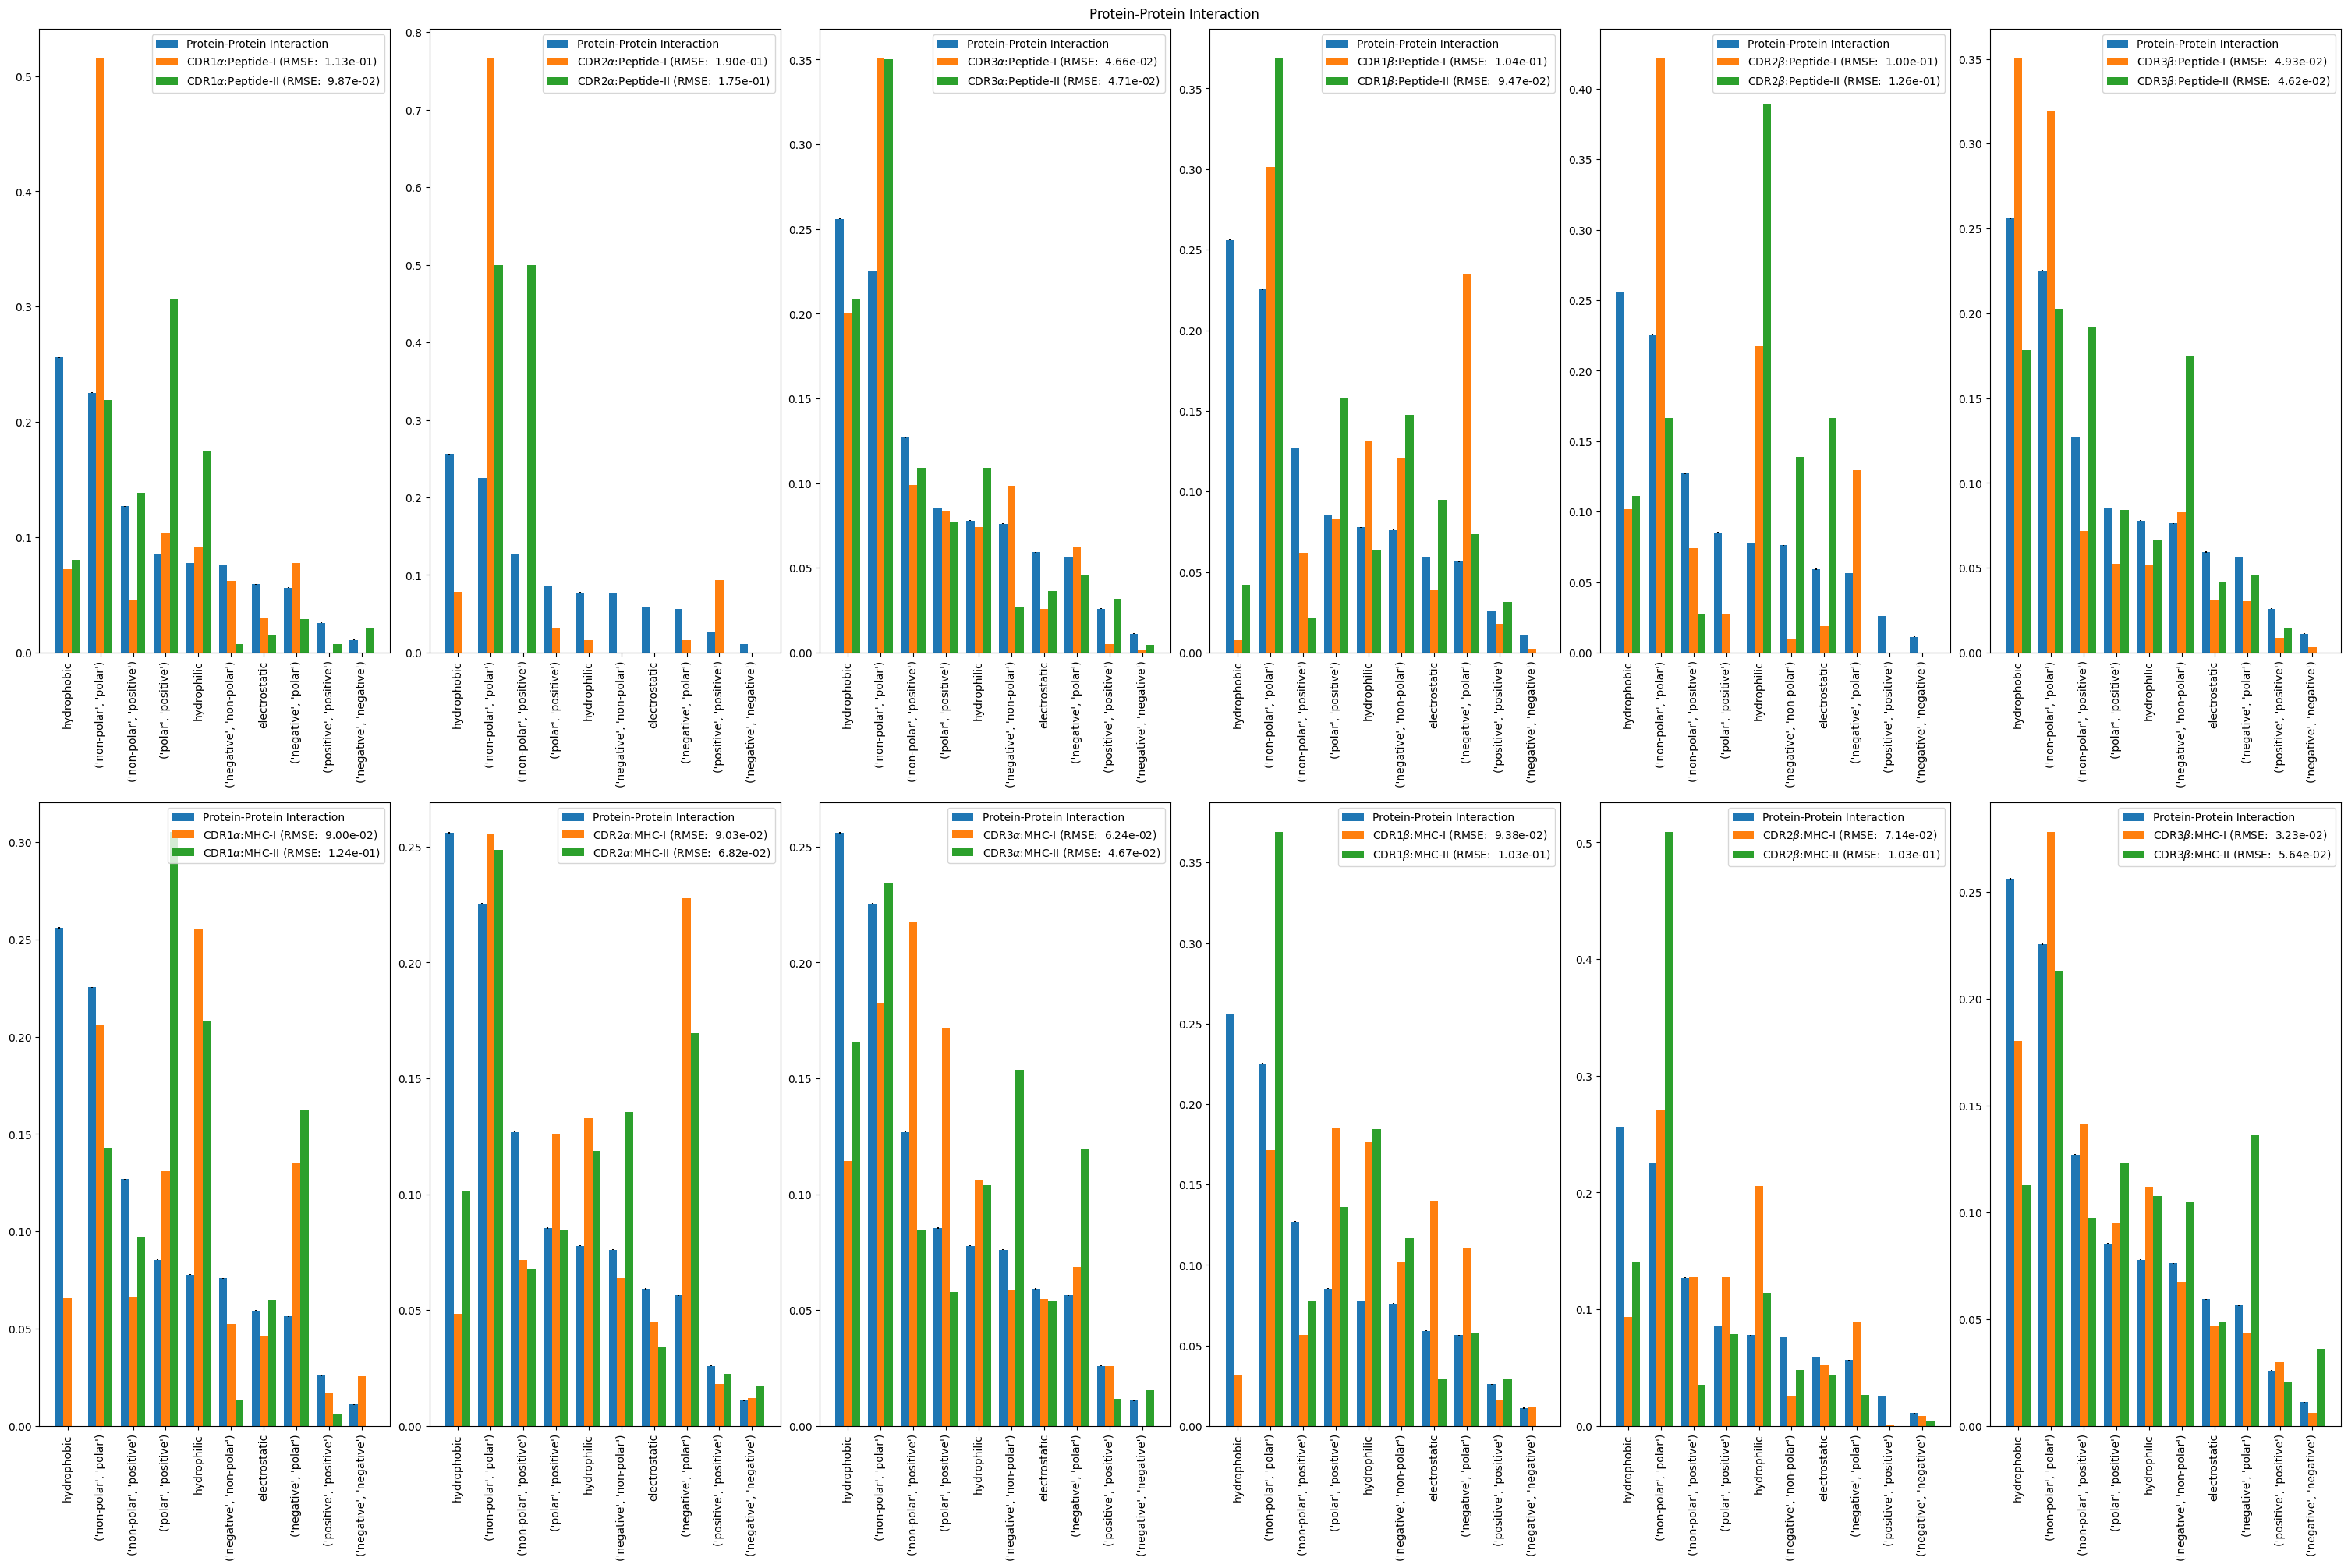

In [39]:
for interaction_type in ('protein_peptide_interaction', 'protein_protein_interaction'):
    fig, axes = plt.subplots(nrows=2, ncols=6, layout='constrained', figsize=(30, 20))

    for i, mhc_component in enumerate(('peptide', 'mhc')):
        for j, cdr_type in enumerate(
            [f'CDR{number}{chain_type}' for chain_type in ('alpha', 'beta') for number in (1, 2, 3)]
        ):
            selected_ppi = ppi_contacting_residues_agg_table.sort_values(
                ('proportion_mean_interaction_type_norm', interaction_type), ascending=False
            )

            x = np.arange(len(selected_ppi.index))
            width = 0.25

            axes[i, j].bar(
                x,
                selected_ppi['proportion_mean_interaction_type_norm'][interaction_type],
                width=width,
                label=interaction_type.replace('_', ' ').title().replace(' ', '-', 1),
            )

            axes[i, j].errorbar(
                x,
                selected_ppi['proportion_mean_interaction_type_norm'][interaction_type],
                yerr=1.96 * selected_ppi['proportion_se_interaction_type_norm'][interaction_type],
                ls='none',
                color='black',
            )

            for multiplier, mhc_type in enumerate(('MH1', 'MH2'), 1):
                selected_tcr_mhc = tcr_pmhc_contacting_residues_cdr_type_agg[
                    (tcr_pmhc_contacting_residues_cdr_type_agg['mhc_type'] == mhc_type)
                    & (tcr_pmhc_contacting_residues_cdr_type_agg['mhc_component'] == mhc_component)
                    & (tcr_pmhc_contacting_residues_cdr_type_agg['cdr_type'] == cdr_type)
                ].copy()

                selected_tcr_mhc = selected_tcr_mhc.set_index('interaction_classification')
                selected_tcr_mhc = selected_tcr_mhc.reindex(selected_ppi.index.tolist())
                selected_tcr_mhc.index = pd.CategoricalIndex(
                    selected_tcr_mhc.index,
                    categories=selected_ppi.index.tolist(),
                    ordered=True,
                )
                selected_tcr_mhc = selected_tcr_mhc.sort_index()

                selected_tcr_mhc['proportion_mhc_type_mhc_component_cdr_type_norm'] = selected_tcr_mhc[
                    'proportion_mhc_type_mhc_component_cdr_type_norm'
                ].fillna(0.0)

                rmse = np.sqrt(
                    np.sum(
                        np.square(
                            selected_ppi['proportion_mean_interaction_type_norm'][interaction_type]
                            - selected_tcr_mhc['proportion_mhc_type_mhc_component_cdr_type_norm']
                        )
                    )
                    / len(selected_ppi['proportion_mean_interaction_type_norm'][interaction_type])
                )

                cdr_type_formatted = cdr_type.replace('alpha', '$\\alpha$').replace('beta', '$\\beta$')
                label = (
                    f"{cdr_type_formatted}:{'Peptide' if mhc_component == 'peptide' else 'MHC'}"
                    f"-{'I' if mhc_type == 'MH1' else 'II'}"
                    f" (RMSE: {rmse: .2e})"
                )

                axes[i, j].bar(
                    x + multiplier * width,
                    selected_tcr_mhc['proportion_mhc_type_mhc_component_cdr_type_norm'],
                    width=width,
                    label=label,
                )

            axes[i, j].set_xticks(x + width, selected_ppi.index, rotation=90)
            axes[i, j].legend()

    fig.suptitle(interaction_type.replace('_', ' ').title().replace(' ', '-', 1))
    plt.show()